In [1]:
pip install earthengine-api geemap --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 51.5 MB/s eta 0:00:0000:0100:01


# Using the OSM GEE account
## Cloud Project: osmgee
## Quota tier: Partner Tier (Until October)

In [2]:
import ee
import geemap
ee.Authenticate()
# Initialize with your project
ee.Initialize(project='osmgee')

## The wetland and contributing watershed, provided by Dr. Zhibang Lv, have been uploaded to GEE assests.

In [3]:
# ============================================
# STEP 1: Load assets and define study parameters
# ============================================

# Load the two feature collections — kept separate for later zonal extraction
wetlands = ee.FeatureCollection('projects/osmgee/assets/OSM_Wetland')
watersheds = ee.FeatureCollection('projects/osmgee/assets/OSM_Watersheds')

# Quick sanity checks
print('Wetland feature count:', wetlands.size().getInfo())
print('Watershed feature count:', watersheds.size().getInfo())
print('First wetland feature:', wetlands.first().getInfo())
print('First watershed feature:', watersheds.first().getInfo())

# ------------------------------------------------------------------
# Two distinct study areas, kept separate for later NDVI extraction:
#   - wetland_geom    : union of all 121 wetland polygons
#   - watershed_geom  : union of all 121 watershed polygons
# ------------------------------------------------------------------
wetland_geom = wetlands.geometry()
watershed_geom = watersheds.geometry()

# Combined bounding geometry — used ONLY to filter the Landsat collection
study_area = watershed_geom.union(wetland_geom).dissolve()

print('Wetland geometry type:', wetland_geom.type().getInfo())
print('Watershed geometry type:', watershed_geom.type().getInfo())

Wetland feature count: 121
Watershed feature count: 121
First wetland feature: {'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[-111.70390746799144, 57.22722193224847], [-111.70391185654573, 57.22717299079201], [-111.70389666527063, 57.22715918120957], [-111.70384392025571, 57.227104209493945], [-111.70378135243628, 57.22706685491684], [-111.70374428383869, 57.22702126090118], [-111.70371543581047, 57.226975806688564], [-111.70368415209386, 57.22695712938566], [-111.70361273164801, 57.22692852811409], [-111.70358953405798, 57.22691001494814], [-111.7035381104251, 57.226841771953424], [-111.7035068269658, 57.22682309461844], [-111.70346662209924, 57.226813092483575], [-111.70342091502113, 57.2267716880284], [-111.70335834845145, 57.22673433330282], [-111.70333486895083, 57.226720305742965], [-111.70329466430755, 57.226710303547996], [-111.70326344947281, 57.226691704283525], [-111.70324073726775, 57.22666875921929], [-111.70315517682813, 57.22661294497201], [-111.70

## Focusing only on the summer composites for clear observations

In [4]:
# ============================================
# Study period and growing season window
# ============================================
start_year = 1985
end_year = 2025

start_month = 6   # June
end_month = 8     # August

In [5]:
# ============================================
# STEP 2: Build harmonized Landsat collection (1985-2025)
# ============================================

"""Cloud/shadow/snow mask for Landsat 4/5/7 Collection 2 SR."""
def mask_l457(image):
    qa = image.select('QA_PIXEL')
    # Bits: 1=Dilated Cloud, 3=Cloud, 4=Cloud Shadow, 5=Snow
    cloud_shadow_bit = 1 << 4
    clouds_bit = 1 << 3
    snow_bit = 1 << 5
    mask = (qa.bitwiseAnd(cloud_shadow_bit).eq(0)
            .And(qa.bitwiseAnd(clouds_bit).eq(0))
            .And(qa.bitwiseAnd(snow_bit).eq(0)))
    return image.updateMask(mask)


def mask_l89(image):
    """Cloud/shadow/snow mask for Landsat 8/9 Collection 2 SR."""
    qa = image.select('QA_PIXEL')
    cloud_shadow_bit = 1 << 4
    clouds_bit = 1 << 3
    snow_bit = 1 << 5
    mask = (qa.bitwiseAnd(cloud_shadow_bit).eq(0)
            .And(qa.bitwiseAnd(clouds_bit).eq(0))
            .And(qa.bitwiseAnd(snow_bit).eq(0)))
    return image.updateMask(mask)


"""Harmonize Landsat 4/5/7 band names to common names."""
def rename_l457(image):
    """Harmonize Landsat 4/5/7 band names to common names."""
    return image.select(
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'],
        ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
    ).copyProperties(image, ['system:time_start', 'SPACECRAFT_ID'])


def rename_l89(image):
    """Harmonize Landsat 8/9 band names to common names."""
    return image.select(
        ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'],
        ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
    ).copyProperties(image, ['system:time_start', 'SPACECRAFT_ID'])


def apply_scale_factors(image):
    """Apply Collection 2 SR scale factors to get true reflectance."""
    optical_bands = image.select(
        ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
    ).multiply(0.0000275).add(-0.2)
    return image.addBands(optical_bands, None, True)


# Load each sensor's Collection 2 Level-2 SR collection, filtered to study area + date range
l5 = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
      .filterBounds(study_area)
      .filterDate('1985-01-01', '2013-01-01')
      .map(mask_l457)
      .map(rename_l457))

l7 = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
      .filterBounds(study_area)
      .filterDate('1999-01-01', '2022-01-01')  # SLC-off after 2003, but keep for gap-fill overlap
      .map(mask_l457)
      .map(rename_l457))

l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
      .filterBounds(study_area)
      .filterDate('2013-01-01', '2025-12-31')
      .map(mask_l89)
      .map(rename_l89))

l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
      .filterBounds(study_area)
      .filterDate('2021-10-01', '2025-12-31')
      .map(mask_l89)
      .map(rename_l89))

# Merge all sensors into one collection, apply scale factors, keep SPACECRAFT_ID
landsat_all = (l5.merge(l7).merge(l8).merge(l9)
               .map(apply_scale_factors))

print('Total merged Landsat scenes:', landsat_all.size().getInfo())

# Sanity check — inspect one image's bands and a property
first_img = landsat_all.first()
print('Band names:', first_img.bandNames().getInfo())
print('SPACECRAFT_ID:', first_img.get('SPACECRAFT_ID').getInfo())

Total merged Landsat scenes: 6724
Band names: ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
SPACECRAFT_ID: LANDSAT_5


## 50% Cloud cover has been used.

In [6]:
# ============================================
# Filter to growing season + sort by cloud cover
# ============================================

def add_cloud_cover_property(image):
    """Ensure CLOUD_COVER is accessible as a numeric property for sorting/filtering."""
    return image.set('CLOUD_COVER', ee.Number(image.get('CLOUD_COVER')))


# Filter the merged collection to the growing season window (across all years)
landsat_growing_season = (landsat_all
    .filter(ee.Filter.calendarRange(start_month, end_month, 'month'))
    .filter(ee.Filter.calendarRange(start_year, end_year, 'year'))
    .map(add_cloud_cover_property))

# Optional: drop scenes above a cloud cover threshold before compositing
# (adjust threshold based on how much data you have available in this region —
#  AOSR has persistent cloud cover per your Project Report Section 2.5, so a
#  very strict threshold may over-thin the collection)
MAX_CLOUD_COVER = 50  # percent

landsat_filtered = landsat_growing_season.filter(
    ee.Filter.lte('CLOUD_COVER', MAX_CLOUD_COVER)
)

# Sort by cloud cover (ascending — least cloudy first)
# Note: sorting an ImageCollection matters most when you later use
# qualityMosaic(), mosaic(), or .first() — median() composites are
# order-independent, so sorting mainly helps downstream flexibility
landsat_sorted = landsat_filtered.sort('CLOUD_COVER')

print('Scenes before cloud filter:', landsat_growing_season.size().getInfo())
print('Scenes after cloud filter (<= {}%):'.format(MAX_CLOUD_COVER),
      landsat_filtered.size().getInfo())

# Sanity check — confirm sort worked, look at cloud cover of first few images
cloud_values = landsat_sorted.limit(5).aggregate_array('CLOUD_COVER').getInfo()
print('Cloud cover of 5 least-cloudy scenes:', cloud_values)

Scenes before cloud filter: 2467
Scenes after cloud filter (<= 50%): 1402
Cloud cover of 5 least-cloudy scenes: [0, 0, 0, 0, 0]


In [7]:
def clip_to_study_area(image):
    """Clip image to study area to reduce computation to only relevant pixels."""
    return image.clip(study_area)


# Apply clipping when building landsat_all, or as an additional .map() step
landsat_all_clipped = landsat_all.map(clip_to_study_area)


# Cross Sensor harmonization is not needed 

## (https://gis.stackexchange.com/questions/440988/landsat-collection-2-surface-reflectance-harmonization
## https://developers.google.com/earth-engine/faq#is_cross-sensor_landsat_surface_reflectance_harmonization_needed)

In [8]:
# ============================================
# Filter clipped collection to growing season, compute NDVI
# ============================================

def add_ndvi(image):
    """Compute NDVI and add as a band."""
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')
    return image.addBands(ndvi)


landsat_ndvi = (landsat_all_clipped
    .filter(ee.Filter.calendarRange(start_month, end_month, 'month'))
    .map(add_ndvi))

print('Scenes in June-Aug window (all years):', landsat_ndvi.size().getInfo())

Scenes in June-Aug window (all years): 2467


In [9]:
# ============================================
# STEP 3: Annual NDVI-only medoid composites (June-August, 1985-2025)
# ============================================

def medoid_composite_ndvi(collection):
    """
    Build a medoid composite using ONLY the NDVI band.
    For each pixel, selects the actual observed NDVI value closest
    to the median NDVI across all available scenes that year.
    """
    median_ndvi = collection.select('NDVI').median()

    def add_distance(image):
        distance = image.select('NDVI').subtract(median_ndvi).abs().rename('distance')
        return image.addBands(distance)

    with_distance = collection.map(add_distance)

    def negate_distance(image):
        return image.addBands(image.select('distance').multiply(-1).rename('neg_distance'))

    with_neg_distance = with_distance.map(negate_distance)

    medoid = with_neg_distance.qualityMosaic('neg_distance')

    return medoid.select('NDVI')


def make_annual_composite(year):
    """Build one annual NDVI-only medoid composite for a given year."""
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, start_month, 1)
    end = ee.Date.fromYMD(year, end_month, 31)

    yearly_scenes = landsat_ndvi.filterDate(start, end.advance(1, 'day'))

    composite = (medoid_composite_ndvi(yearly_scenes)
        .set('year', year)
        .set('system:time_start', start.millis())
        .set('scene_count', yearly_scenes.size()))

    return composite

In [40]:
# Test on a single year first
test_composite = make_annual_composite(2008)

print('Test composite bands:', test_composite.bandNames().getInfo())
print('Test composite scene count:', test_composite.get('scene_count').getInfo())

test_thumb_url = test_composite.select('NDVI').getThumbURL({
    'min': -0.2,
    'max': 0.9,
    'palette': ['brown', 'yellow', 'green', 'darkgreen'],
    'dimensions': 512,
    'region': study_area,
})

from IPython.display import Image as IPImage
IPImage(url=test_thumb_url)

Test composite bands: ['NDVI']


Test composite scene count: 67


In [41]:
# ============================================
# Export test composite (2008 NDVI medoid) to GEE Asset
# ============================================

export_task_asset = ee.batch.Export.image.toAsset(
    image=test_composite,
    description='NDVI_medoid_2008_test',
    assetId='projects/annual-ccdc-new/assets/NDVI_medoid_2008_test',
    region=study_area,
    scale=30,
    maxPixels=1e9
)

export_task_asset.start()
print('Export to Asset started. Task ID:', export_task_asset.id)

Export to Asset started. Task ID: MDSLJELXQ742XJUGKZHJ5LAK


In [12]:
import time

task = export_task_asset  # or export_task_drive
while task.active():
    print('Task status:', task.status()['state'])
    time.sleep(30)

print('Final status:', task.status())

Task status: READY
Final status: {'state': 'FAILED', 'description': 'NDVI_medoid_1985_test', 'priority': 100, 'creation_timestamp_ms': 1788052692630, 'update_timestamp_ms': 1788052697446, 'start_timestamp_ms': 1788052696901, 'task_type': 'EXPORT_IMAGE', 'attempt': 1, 'error_message': "Cannot overwrite asset 'projects/annual-ccdc-new/assets/NDVI_medoid_1985_test'.", 'id': 'A4NLQUG5K3ZPL5VKSHMNBATS', 'name': 'projects/osmgee/operations/A4NLQUG5K3ZPL5VKSHMNBATS'}


In [42]:
# ============================================
# Import all annual NDVI medoid composites (1985-2025) from GEE Assets
# ============================================

ASSET_PROJECT = 'projects/annual-ccdc-new/assets'

def load_annual_composite(year):
    """Load one year's exported NDVI medoid composite as an ee.Image, tagged with its year."""
    asset_id = f'{ASSET_PROJECT}/NDVI_medoid_{year}_test'
    img = ee.Image(asset_id).set('year', year)
    return img

# Build the full 1985-2025 collection from individually exported assets
years_range = list(range(1985, 2026))
annual_images = [load_annual_composite(y) for y in years_range]

annual_ndvi_collection = ee.ImageCollection.fromImages(annual_images)

print('Number of years expected:', len(years_range))

Number of years expected: 41


In [43]:
# ============================================
# Verify all 41 expected assets actually exist before using them
# ============================================

existing_assets = ee.data.listAssets({'parent': ASSET_PROJECT})
existing_ids = set(a['id'] for a in existing_assets.get('assets', []))

missing_years = []
found_years = []

for year in years_range:
    expected_id = f'{ASSET_PROJECT}/NDVI_medoid_{year}_test'
    if expected_id in existing_ids:
        found_years.append(year)
    else:
        missing_years.append(year)

print(f'Found: {len(found_years)} / {len(years_range)} years')
if missing_years:
    print('Missing years:', missing_years)
else:
    print('All 41 years present.')

Found: 41 / 41 years
All 41 years present.


In [44]:
# ============================================
# Compute spatial mean NDVI per year — SEPARATELY for wetlands and watersheds
# ============================================

def get_mean_ndvi(image, geom):
    """Compute the spatial mean NDVI over a given geometry for one year's composite."""
    mean_dict = image.select('NDVI').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )
    return image.set('mean_ndvi', mean_dict.get('NDVI'))


def get_mean_ndvi_wetland(image):
    return get_mean_ndvi(image, wetland_geom)


def get_mean_ndvi_watershed(image):
    return get_mean_ndvi(image, watershed_geom)


# Map separately over the same 41-year collection, using each geometry
annual_wetland_mean = annual_ndvi_collection.map(get_mean_ndvi_wetland)
annual_watershed_mean = annual_ndvi_collection.map(get_mean_ndvi_watershed)

# Pull results back to Python
years_list = annual_wetland_mean.aggregate_array('year').getInfo()
mean_ndvi_wetland = annual_wetland_mean.aggregate_array('mean_ndvi').getInfo()
mean_ndvi_watershed = annual_watershed_mean.aggregate_array('mean_ndvi').getInfo()

print('Years:', years_list)
print('Wetland mean NDVI:', mean_ndvi_wetland)
print('Watershed mean NDVI:', mean_ndvi_watershed)

Years: [1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Wetland mean NDVI: [0.646736176701089, 0.6552559178476562, 0.6668271139426163, 0.6933285598946476, 0.717781082665478, 0.7062103220124024, 0.6699450188405928, 0.6375089909205139, 0.6207839267234282, 0.6297155897835732, 0.5848083635963843, 0.6777987649207021, 0.6749729099889955, 0.6253922529548718, 0.6185290914927714, 0.6632885514353825, 0.6918773916037927, 0.5829118055404825, 0.6705133086580765, 0.638754897708926, 0.6384081343194199, 0.6654337972905287, 0.6531809228324816, 0.6976209019590978, 0.6789440964829733, 0.654762690168075, 0.6604543940453588, 0.672239355009803, 0.7401165721679112, 0.7321912395366377, 0.6413435185351107, 0.6836236047895031, 0.7026853054662946, 0.6877532134108874, 0.6719031298435125, 0.74169168600606, 0.71550605609

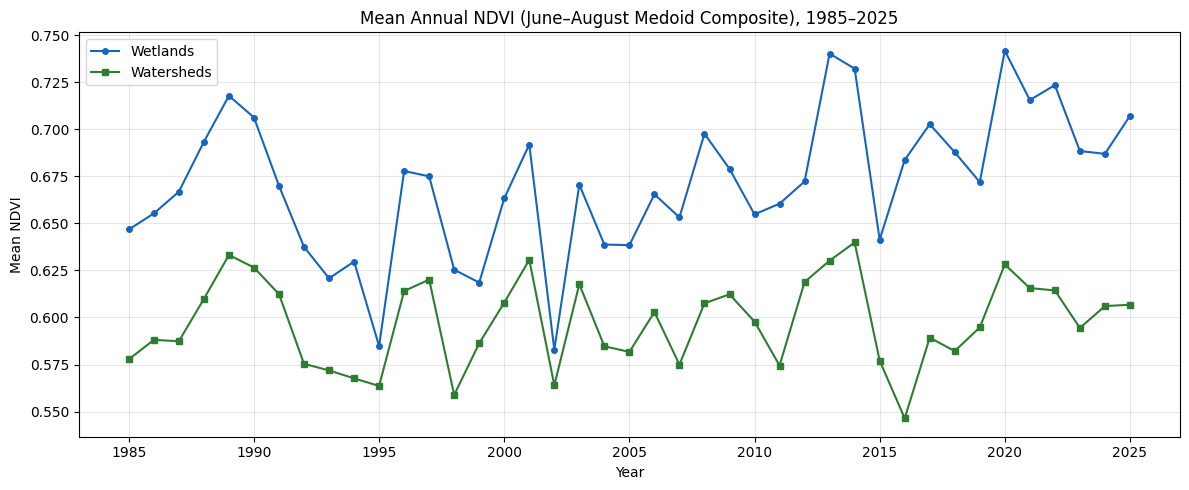

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(years_list, mean_ndvi_wetland, marker='o', markersize=4,
         linewidth=1.5, color='#1565C0', label='Wetlands')
plt.plot(years_list, mean_ndvi_watershed, marker='s', markersize=4,
         linewidth=1.5, color='#2E7D32', label='Watersheds')
plt.xlabel('Year')
plt.ylabel('Mean NDVI')
plt.title('Mean Annual NDVI (June–August Medoid Composite), 1985–2025')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ndvi_timeseries_wetland_vs_watershed.png', dpi=150)
plt.show()

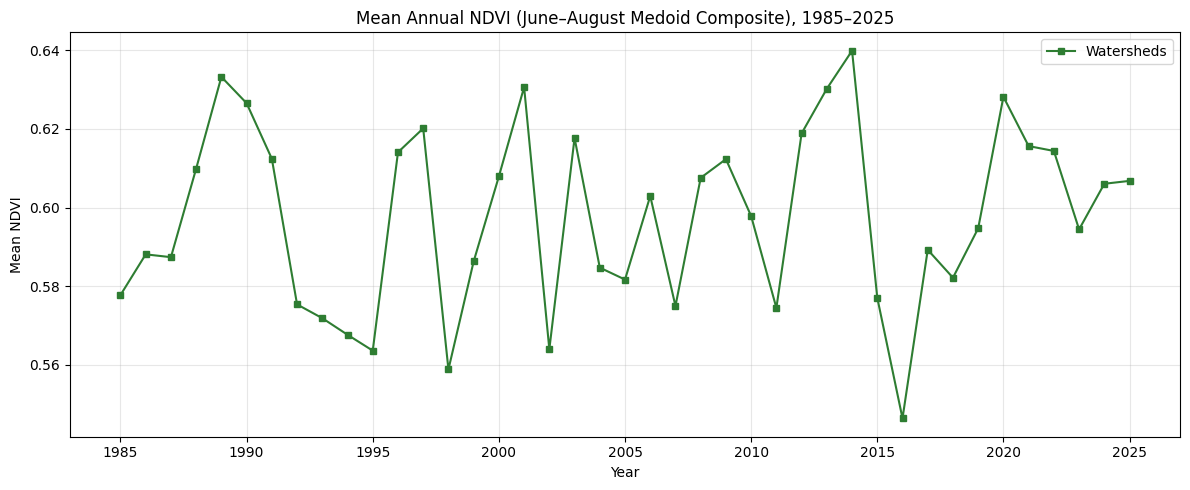

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(years_list, mean_ndvi_watershed, marker='s', markersize=4,
         linewidth=1.5, color='#2E7D32', label='Watersheds')
plt.xlabel('Year')
plt.ylabel('Mean NDVI')
plt.title('Mean Annual NDVI (June–August Medoid Composite), 1985–2025')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ndvi_timeseries_watershed.png', dpi=150)
plt.show()

In [47]:
# ============================================
# Pre-compute the difference geometry ONCE, not per-year
# ============================================

# Force evaluation now, so it's computed a single time rather than
# being silently recomputed inside every one of the 41 map() calls
watershed_minus_wetland_geom = ee.Geometry(
    watershed_geom.difference(wetland_geom, maxError=1).getInfo()
)

print('Difference geometry computed and materialized.')

Difference geometry computed and materialized.


https://earthengine.googleapis.com/v1/projects/osmgee/thumbnails/04411cd7775ea421e60f84e0aa78f306-9a3277d98896f5ffd78ced6d205e1db2:getPixels


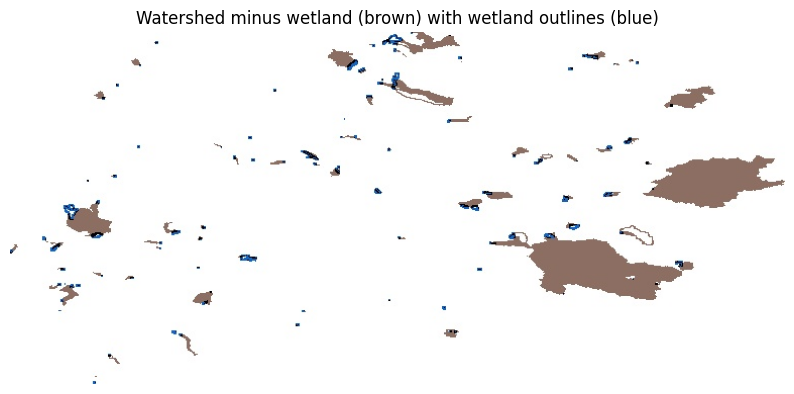

In [48]:
# ============================================
# Visualize watershed-minus-wetland geometry
# ============================================

# Paint the difference geometry onto a blank image
diff_feature = ee.FeatureCollection([ee.Feature(watershed_minus_wetland_geom)])

diff_image = ee.Image().byte().paint(
    featureCollection=diff_feature,
    color=1
)

# Also paint the original wetlands on top, in a different value, so you can
# see both layers together and visually confirm the wetland "holes"
wetland_outline = ee.Image().byte().paint(
    featureCollection=wetlands,
    color=2,
    width=2  # outline only, so it doesn't just fully overlap/hide
)

combined_vis = diff_image.unmask(0).add(wetland_outline.unmask(0))

thumb_url = combined_vis.getThumbURL({
    'min': 0,
    'max': 3,
    'palette': ['white', '#8D6E63', '#1565C0', 'black'],  # 0=empty, 1=upland, 2=wetland outline
    'dimensions': 768,
    'region': watershed_geom,
})

print(thumb_url)

import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

response = requests.get(thumb_url)
img = Image.open(BytesIO(response.content))

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.title('Watershed minus wetland (brown) with wetland outlines (blue)')
plt.show()

In [49]:
# ============================================
# Compute spatial mean NDVI per year — using the pre-computed geometry
# ============================================

def get_mean_ndvi_upland(image):
    mean_dict = image.select('NDVI').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=watershed_minus_wetland_geom,
        scale=30,
        maxPixels=1e9,
        bestEffort=True
    )
    return image.set('mean_ndvi', mean_dict.get('NDVI'))


annual_upland_mean = annual_ndvi_collection.map(get_mean_ndvi_upland)

years_upland_list = annual_upland_mean.aggregate_array('year').getInfo()
mean_ndvi_upland = annual_upland_mean.aggregate_array('mean_ndvi').getInfo()

print('Years:', years_upland_list)
print('Watershed-minus-wetland mean NDVI:', mean_ndvi_upland)

Years: [1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Watershed-minus-wetland mean NDVI: [0.5757138750154018, 0.5861021461978994, 0.5852203983566803, 0.6073879080126757, 0.6306366781671782, 0.6241335989655711, 0.6107565350654265, 0.5735814435888914, 0.5705010416341586, 0.5658943295918193, 0.5631488316375738, 0.6121715120503888, 0.6185165518885153, 0.5569411556961994, 0.5855247413705936, 0.6063750294834872, 0.6288275718222381, 0.5636210087872822, 0.6161837067757027, 0.5831795808985287, 0.5800311769347435, 0.6011079462456967, 0.572620598767602, 0.6048201515659831, 0.6103062644887419, 0.5961705961416417, 0.5718807236371864, 0.6173406423051927, 0.6268121728842738, 0.6370526533539006, 0.5752868839441937, 0.5422871081636382, 0.5858658321988918, 0.5789827902831611, 0.5924901519595904, 0.624699130

NameError: name 'years_watershed_list' is not defined

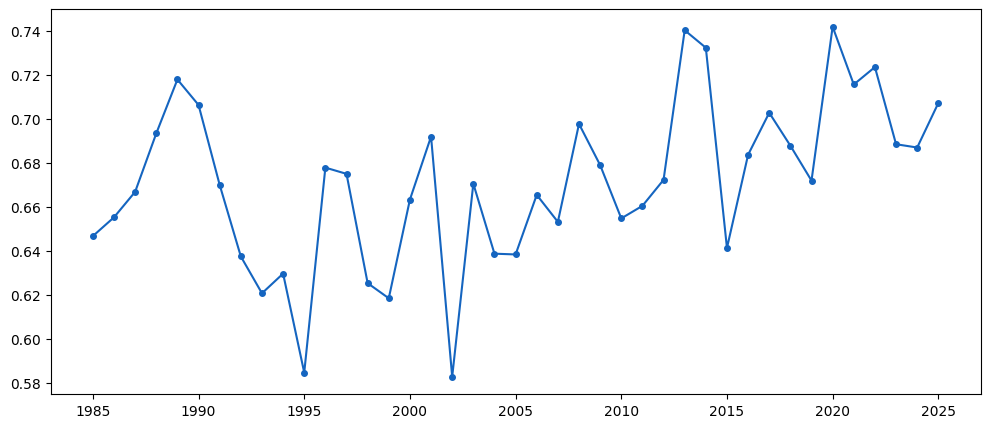

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(years_list, mean_ndvi_wetland, marker='o', markersize=4,
         linewidth=1.5, color='#1565C0', label='Wetlands')
plt.plot(years_watershed_list, mean_ndvi_watershed, marker='s', markersize=4,
         linewidth=1.5, color='#2E7D32', label='Watersheds (full, includes wetlands)')
plt.plot(years_upland_list, mean_ndvi_upland, marker='^', markersize=4,
         linewidth=1.5, color='#8D6E63', label='Watersheds minus wetlands (upland only)')
plt.xlabel('Year')
plt.ylabel('Mean NDVI')
plt.title('Mean Annual NDVI (June–August Medoid Composite), 1985–2025')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ndvi_timeseries_three_way.png', dpi=150)
plt.show()

In [ ]:
# ============================================
# Run LandTrendr on the annual NDVI collection (pixel-wise, whole watershed area)
# ============================================

LANDTRENDR_PARAMS = {
    'maxSegments': 6,
    'spikeThreshold': 0.9,
    'vertexCountOvershoot': 3,
    'preventOneYearRecovery': True,
    'recoveryThreshold': 0.25,
    'pvalThreshold': 0.05,
    'bestModelProportion': 0.75,
    'minObservationsNeeded': 6,
}

# LandTrendr requires the collection sorted chronologically, one image per year,
# with the segmentation band as the FIRST band. Our collection is already
# annual and NDVI-only, so we just need to confirm sort order.
lt_collection = annual_ndvi_collection.sort('year')

# Build the LandTrendr input: LT expects the collection wrapped with band = 'NDVI'
lt_params = dict(LANDTRENDR_PARAMS)
lt_params['timeSeries'] = lt_collection.select('NDVI')

lt_result = ee.Algorithms.TemporalSegmentation.LandTrendr(**lt_params)

print('LandTrendr output bands:', lt_result.bandNames().getInfo())

LandTrendr output bands: ['LandTrendr', 'rmse']


In [ ]:
# ============================================
# Unpack LandTrendr fitted values into an annual ImageCollection (FIXED)
# ============================================

lt_array = lt_result.select('LandTrendr')

def get_fitted_year(i):
    """Extract the fitted NDVI value for the i-th year position and tag it with its year."""
    i = ee.Number(i)
    year = ee.Number(start_year).add(i)

    # Explicitly cast the index to an integer-typed image before using it
    # as an arrayGet position argument
    i_int = ee.Image.constant(i).toInt()

    fitted_value = (lt_array
        .arrayGet([1, i_int])  # row 1 = fitted values, column i = year index
        .rename('NDVI_fitted'))

    return fitted_value.set('year', year)


n_years = end_year - start_year + 1
year_indices = ee.List.sequence(0, n_years - 1)

fitted_images_list = year_indices.map(get_fitted_year)
fitted_ndvi_collection = ee.ImageCollection.fromImages(fitted_images_list)

print('Fitted collection size:', fitted_ndvi_collection.size().getInfo())

Fitted collection size: 41


In [54]:
# ============================================
# Export LandTrendr result to GEE Asset (compute once, persist)
# ============================================

lt_export_task = ee.batch.Export.image.toAsset(
    image=lt_result,
    description='LandTrendr_NDVI_watershed_1985_2025',
    assetId='projects/annual-ccdc-new/assets/LandTrendr_NDVI_watershed_1985_2025',
    region=watershed_geom,
    scale=30,
    maxPixels=1e10  # LandTrendr's array bands are large; a higher ceiling helps avoid a separate limit error
)

lt_export_task.start()
print('LandTrendr export started. Task ID:', lt_export_task.id)

LandTrendr export started. Task ID: SWRRCGOXWEL5WE5EIB4XR243


In [ ]:
# ============================================
# Check ONLY years 2005-2012 directly (avoid truncated output)
# ============================================

for y in range(2005, 2013):
    img = annual_ndvi_collection.filter(ee.Filter.eq('year', y)).first()
    ts = img.get('system:time_start').getInfo()
    import datetime
    date_str = datetime.datetime.fromtimestamp(ts / 1000, datetime.UTC).strftime('%Y-%m-%d')
    print(f'{y} -> {date_str}')

2005 -> 2005-06-01
2006 -> 2006-06-01
2007 -> 2009-06-01
2008 -> 2009-06-01
2009 -> 2009-06-01
2010 -> 2010-06-01
2011 -> 2011-06-01
2012 -> 2012-06-01
